# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

## 2. Datos

In [2]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv")

### 2.1 Exploración de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [4]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
907,28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
910,23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
911,229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [6]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


### 2.3 Definir X e y

In [7]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 12)

In [8]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [10]:
X_train

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
25,1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg
84,153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg
10,275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg
342,1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg
890,131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg
...,...,...,...,...,...,...,...,...,...,...,...,...
106,578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,1.94kg
270,996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg
860,770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.18kg
435,407,Lenovo,IdeaPad 320-15IAP,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 1.1GHz,4GB,1TB HDD,Intel HD Graphics 500,Windows 10,2.2kg


In [11]:
col = X_train.columns.to_list()

for c in col:
    print(f'Para la columna {c}, hay estas clases:{X_train[c].nunique()}')

Para la columna laptop_ID, hay estas clases:729
Para la columna Company, hay estas clases:17
Para la columna Product, hay estas clases:408
Para la columna TypeName, hay estas clases:6
Para la columna Inches, hay estas clases:15
Para la columna ScreenResolution, hay estas clases:33
Para la columna Cpu, hay estas clases:93
Para la columna Ram, hay estas clases:8
Para la columna Memory, hay estas clases:33
Para la columna Gpu, hay estas clases:84
Para la columna OpSys, hay estas clases:9
Para la columna Weight, hay estas clases:148


**Convertir variables a numéricas**

In [12]:
def preprocess_features(df):
    df = df.copy()

    # -----------------------------
    # 1. RAM → numérico
    # -----------------------------
    df["Ram"] = df["Ram"].astype(str).str.replace("GB", "", regex=False).astype(int)

    # -----------------------------
    # 2. Weight → numérico
    # -----------------------------
    df["Weight"] = df["Weight"].astype(str).str.replace("kg", "", regex=False).astype(float)

    # -----------------------------
    # 3. ScreenResolution → X_res, Y_res, PPI
    # -----------------------------
    df["X_res"] = df["ScreenResolution"].astype(str).str.extract(r'(\d+)x').astype(int)
    df["Y_res"] = df["ScreenResolution"].astype(str).str.extract(r'x(\d+)').astype(int)
    df["PPI"] = ((df["X_res"]**2 + df["Y_res"]**2)**0.5 / df["Inches"])

    df["IPS"] = df["ScreenResolution"].astype(str).str.contains("IPS", case=False).astype(int)
    df["Touchscreen"] = df["ScreenResolution"].astype(str).str.contains("Touchscreen", case=False).astype(int)

    # -----------------------------
    # 4. CPU → frecuencia
    # -----------------------------
    df["Cpu_freq"] = df["Cpu"].astype(str).str.extract(r'(\d+\.\d+)').astype(float)


    # -----------------------------
    # 5. Memory → SSD
    # -----------------------------
    df["SSD"] = df["Memory"].astype(str).str.extract(r'(\d+)GB SSD').fillna(0).astype(int)

    # -----------------------------
    # 6. Dummies necesarias
    # -----------------------------
    df = pd.get_dummies(df, columns=["Company", "TypeName", "Gpu"], drop_first=False)

    # -----------------------------
    # 7. Selección final de columnas
    # -----------------------------
    final_cols = [
        "Ram", "Weight", "IPS", "Touchscreen",
        "X_res", "Y_res", "PPI", "Cpu_freq", "SSD",
        "Company_Razer",
        "TypeName_Gaming", "TypeName_Notebook",
        "TypeName_Ultrabook", "TypeName_Workstation",
        "Gpu_brand_Nvidia"
    ]

    # Crear columnas faltantes en test
    for col in final_cols:
        if col not in df.columns:
            df[col] = 0

    return df[final_cols]

In [13]:
X_train = preprocess_features(X_train)
X_test = preprocess_features(X_test)


In [14]:
X_train

,Ram,Weight,IPS,Touchscreen,X_res,Y_res,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Gpu_brand_Nvidia
25,8,3.00,1,0,1920,1080,127.335675,2.6,0,False,False,False,False,True,0
84,16,2.56,0,0,1920,1080,141.211998,2.8,512,False,True,False,False,False,0
10,8,1.37,1,0,2560,1600,226.983005,2.9,512,False,False,False,True,False,0
342,4,1.54,0,0,1920,1080,157.350512,2.3,0,False,False,True,False,False,0
890,16,2.80,0,0,1920,1080,127.335675,1.8,256,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,8,1.94,0,0,1366,768,111.935204,1.6,0,False,False,True,False,False,0
270,6,2.20,0,0,1920,1080,141.211998,3.6,256,False,False,True,False,False,0
860,16,1.18,0,0,1920,1080,176.232574,2.8,256,False,False,False,True,False,0
435,4,2.20,0,0,1366,768,100.454670,1.1,0,False,False,True,False,False,0


In [15]:
X_test

,Ram,Weight,IPS,Touchscreen,X_res,Y_res,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Gpu_brand_Nvidia
649,8,2.20,1,0,1920,1080,141.211998,2.8,128,False,True,False,False,False,0
761,8,2.08,0,1,1920,1080,141.211998,2.5,256,False,False,False,False,False,0
545,8,1.87,1,0,1920,1080,157.350512,2.5,256,False,False,True,False,False,0
367,4,1.63,1,1,1920,1080,157.350512,2.4,128,False,False,False,False,False,0
361,4,2.20,0,0,1366,768,100.454670,1.6,0,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,8,1.86,0,0,1920,1080,141.211998,2.5,0,False,False,True,False,False,0
581,4,1.25,1,1,1366,768,135.094211,1.6,0,False,False,False,False,False,0
872,2,1.15,0,0,1366,768,135.094211,1.1,0,False,False,True,False,False,0
449,8,1.87,1,0,1920,1080,157.350512,2.7,256,False,False,True,False,False,0


In [16]:
corrs = X_train.corrwith(y_train, numeric_only=True).sort_values(ascending=False)
corrs


c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\blanc.TORRE-BLANCA\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Ram                     0.744269
Y_res                   0.544696
X_res                   0.544053
SSD                     0.527424
PPI                     0.466640
Cpu_freq                0.419089
TypeName_Gaming         0.399879
IPS                     0.269970
TypeName_Ultrabook      0.269501
Touchscreen             0.229258
Company_Razer           0.226785
TypeName_Workstation    0.217625
Weight                  0.202341
TypeName_Notebook      -0.576508
Gpu_brand_Nvidia             NaN
dtype: float64

In [17]:
# Calculamos correlaciones
corrs = X_train.corrwith(y_train, numeric_only=True)

# Seleccionamos solo las columnas con correlación >= 0.20
selected_cols = corrs[abs(corrs) >= 0.20].index

# Filtramos X_train y X_test para que solo contengan esas columnas
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]


In [18]:
X_train

,Ram,Weight,IPS,Touchscreen,X_res,Y_res,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
25,8,3.00,1,0,1920,1080,127.335675,2.6,0,False,False,False,False,True
84,16,2.56,0,0,1920,1080,141.211998,2.8,512,False,True,False,False,False
10,8,1.37,1,0,2560,1600,226.983005,2.9,512,False,False,False,True,False
342,4,1.54,0,0,1920,1080,157.350512,2.3,0,False,False,True,False,False
890,16,2.80,0,0,1920,1080,127.335675,1.8,256,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,8,1.94,0,0,1366,768,111.935204,1.6,0,False,False,True,False,False
270,6,2.20,0,0,1920,1080,141.211998,3.6,256,False,False,True,False,False
860,16,1.18,0,0,1920,1080,176.232574,2.8,256,False,False,False,True,False
435,4,2.20,0,0,1366,768,100.454670,1.1,0,False,False,True,False,False


In [19]:
X_test

,Ram,Weight,IPS,Touchscreen,X_res,Y_res,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
649,8,2.20,1,0,1920,1080,141.211998,2.8,128,False,True,False,False,False
761,8,2.08,0,1,1920,1080,141.211998,2.5,256,False,False,False,False,False
545,8,1.87,1,0,1920,1080,157.350512,2.5,256,False,False,True,False,False
367,4,1.63,1,1,1920,1080,157.350512,2.4,128,False,False,False,False,False
361,4,2.20,0,0,1366,768,100.454670,1.6,0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,8,1.86,0,0,1920,1080,141.211998,2.5,0,False,False,True,False,False
581,4,1.25,1,1,1366,768,135.094211,1.6,0,False,False,False,False,False
872,2,1.15,0,0,1366,768,135.094211,1.1,0,False,False,True,False,False
449,8,1.87,1,0,1920,1080,157.350512,2.7,256,False,False,True,False,False


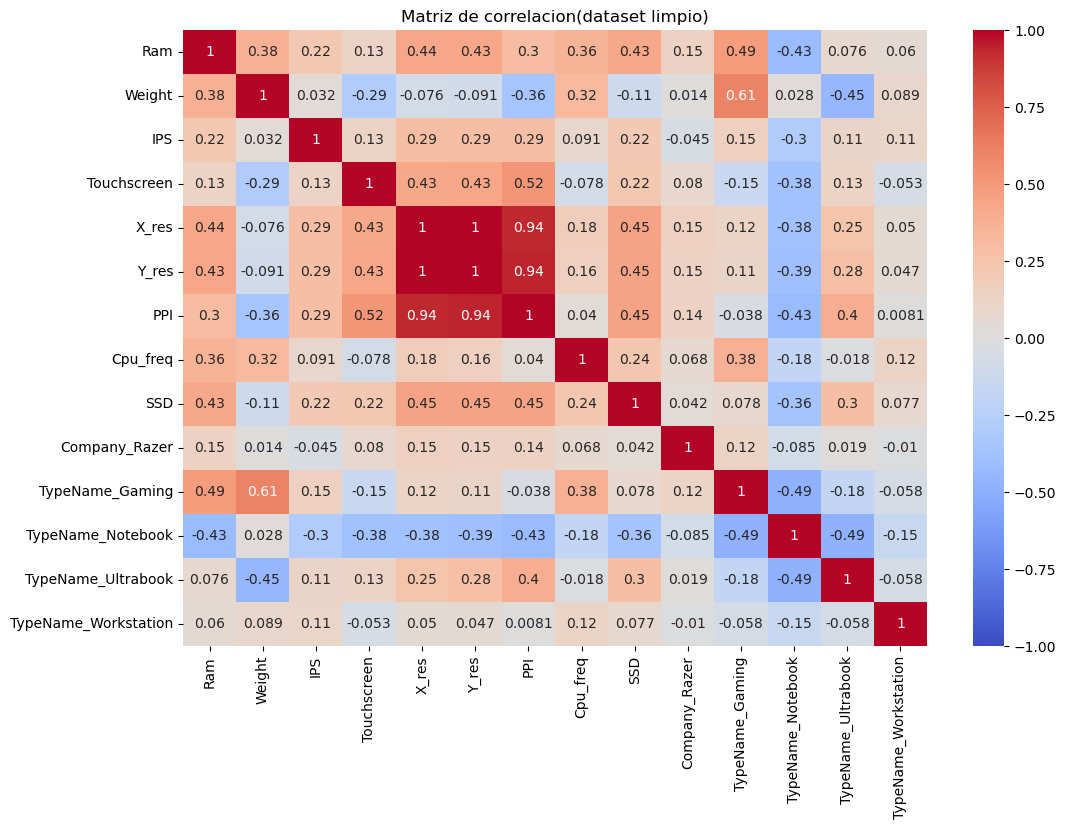

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(
    X_train.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Matriz de correlacion(dataset limpio)')
plt.show()

In [21]:
X_train["Cpu_freq"].unique()
X_train["IPS"].unique()


array([1, 0])

In [22]:
X_train[["Cpu_freq", "IPS"]].corr()


,Cpu_freq,IPS
Cpu_freq,1.00000,0.09134
IPS,0.09134,1.00000


In [23]:
X_train["Cpu_freq"].value_counts()
X_train["IPS"].value_counts()


IPS
0    534
1    195
Name: count, dtype: int64

Eliminamos las variables muy correlacionadas entre ellas 

In [24]:
import numpy as np

corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = to_drop = ["X_res", "Y_res"]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)




In [25]:
X_train

,Ram,Weight,IPS,Touchscreen,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
25,8,3.00,1,0,127.335675,2.6,0,False,False,False,False,True
84,16,2.56,0,0,141.211998,2.8,512,False,True,False,False,False
10,8,1.37,1,0,226.983005,2.9,512,False,False,False,True,False
342,4,1.54,0,0,157.350512,2.3,0,False,False,True,False,False
890,16,2.80,0,0,127.335675,1.8,256,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
106,8,1.94,0,0,111.935204,1.6,0,False,False,True,False,False
270,6,2.20,0,0,141.211998,3.6,256,False,False,True,False,False
860,16,1.18,0,0,176.232574,2.8,256,False,False,False,True,False
435,4,2.20,0,0,100.454670,1.1,0,False,False,True,False,False


In [26]:
X_test

,Ram,Weight,IPS,Touchscreen,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
649,8,2.20,1,0,141.211998,2.8,128,False,True,False,False,False
761,8,2.08,0,1,141.211998,2.5,256,False,False,False,False,False
545,8,1.87,1,0,157.350512,2.5,256,False,False,True,False,False
367,4,1.63,1,1,157.350512,2.4,128,False,False,False,False,False
361,4,2.20,0,0,100.454670,1.6,0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
344,8,1.86,0,0,141.211998,2.5,0,False,False,True,False,False
581,4,1.25,1,1,135.094211,1.6,0,False,False,False,False,False
872,2,1.15,0,0,135.094211,1.1,0,False,False,True,False,False
449,8,1.87,1,0,157.350512,2.7,256,False,False,True,False,False


Creamos una funcion para aplicar los cambios de X_train a X_test 

In [27]:
y_train

25     2899.00
84     1249.26
10     1958.90
342    1030.99
890    1396.00
        ...   
106     389.00
270     549.00
860    1859.00
435     306.00
102    1943.00
Name: Price_in_euros, Length: 729, dtype: float64

In [28]:
X_train.columns.equals(X_test.columns)


True

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [29]:
target = 'Price_in_euros'

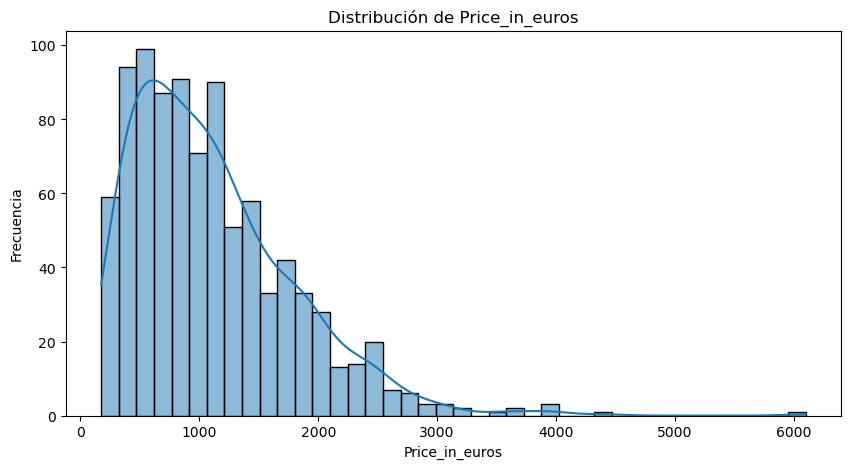

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price_in_euros'], kde=True, bins=40)
plt.title("Distribución de Price_in_euros")
plt.xlabel("Price_in_euros")
plt.ylabel("Frecuencia")
plt.show()

Tiene mucha cola a la derecha y son modelos sensibles a escalas, modelo linal puede verse penalizado. Hacer transformacion log.

Buscar valores NaN en X_train

In [31]:
X_train.isnull().sum()


Ram                      0
Weight                   0
IPS                      0
Touchscreen              0
PPI                      0
Cpu_freq                43
SSD                      0
Company_Razer            0
TypeName_Gaming          0
TypeName_Notebook        0
TypeName_Ultrabook       0
TypeName_Workstation     0
dtype: int64

Imputar valores nulos con la mediana


In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train["Cpu_freq"] = imputer.fit_transform(X_train[["Cpu_freq"]])
X_test["Cpu_freq"] = imputer.transform(X_test[["Cpu_freq"]])

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}


Transformación logarítmica del target

GridSearch sobre el target

**Esto es un modelo con escala logaritmica del target pero no mejora el RMSE final por lo que no lo usaremos**

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [34]:
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    print(f"\nModelo: {nombre}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.3f}")



Modelo: LinearRegression
RMSE: 395.27
R2: 0.718

Modelo: RandomForest
RMSE: 355.77
R2: 0.772

Modelo: GradientBoosting
RMSE: 350.82
R2: 0.778


In [35]:
best_model = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=500,
    subsample=0.8,
    random_state=42
)

best_model.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, n_estimators=500, random_state=42,
                          subsample=0.8)

In [36]:
pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE final:", rmse)
print("R2 final:", r2)


RMSE final: 353.63446288643223
R2 final: 0.7743526206624401


Calcular RSME en euros

In [37]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE final:", rmse)
print("R2 final:", r2)

RMSE final: 353.63446288643223
R2 final: 0.7743526206624401


### 4.3 Optimización (up to you 🫰🏻)

-----------------------------------------------------------------

Tunning hiperparámetros

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor RMSE:", -grid.best_score_)

Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Mejor RMSE: 293.5252438273917


Guardar el modelo entrenado

In [39]:
import joblib

joblib.dump(best_model, "modelo_final.pkl")

['modelo_final.pkl']

In [40]:
import joblib

model = joblib.load("modelo_final.pkl")


## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [41]:
X_pred_raw = pd.read_csv("./data/test.csv")
X_pred = preprocess_features(X_pred_raw)


In [42]:
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)


In [43]:
X_pred.tail()

,Ram,Weight,IPS,Touchscreen,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
386,16,2.90,0,0,127.335675,2.8,512,False,True,False,False,False
387,4,1.47,1,0,157.350512,2.3,128,False,False,True,False,False
388,8,1.78,0,0,141.211998,2.8,256,False,False,False,False,True
389,4,1.64,0,0,111.935204,2.5,0,False,False,True,False,False
390,8,1.27,1,1,165.632118,2.5,256,False,False,False,False,False


In [44]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ram                   391 non-null    int32  
 1   Weight                391 non-null    float64
 2   IPS                   391 non-null    int32  
 3   Touchscreen           391 non-null    int32  
 4   PPI                   391 non-null    float64
 5   Cpu_freq              364 non-null    float64
 6   SSD                   391 non-null    int32  
 7   Company_Razer         391 non-null    bool   
 8   TypeName_Gaming       391 non-null    bool   
 9   TypeName_Notebook     391 non-null    bool   
 10  TypeName_Ultrabook    391 non-null    bool   
 11  TypeName_Workstation  391 non-null    bool   
dtypes: bool(5), float64(3), int32(4)
memory usage: 17.3 KB


Quitar los Nan

In [45]:
cpu_median = X_train["Cpu_freq"].median()

X_pred["Cpu_freq"] = X_pred["Cpu_freq"].fillna(cpu_median)

In [46]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ram                   391 non-null    int32  
 1   Weight                391 non-null    float64
 2   IPS                   391 non-null    int32  
 3   Touchscreen           391 non-null    int32  
 4   PPI                   391 non-null    float64
 5   Cpu_freq              391 non-null    float64
 6   SSD                   391 non-null    int32  
 7   Company_Razer         391 non-null    bool   
 8   TypeName_Gaming       391 non-null    bool   
 9   TypeName_Notebook     391 non-null    bool   
 10  TypeName_Ultrabook    391 non-null    bool   
 11  TypeName_Workstation  391 non-null    bool   
dtypes: bool(5), float64(3), int32(4)
memory usage: 17.3 KB


 ## 2. Replicar el procesado para ``test.csv``

In [47]:
X_pred

,Ram,Weight,IPS,Touchscreen,PPI,Cpu_freq,SSD,Company_Razer,TypeName_Gaming,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
0,16,2.400,0,0,141.211998,2.8,512,False,True,False,False,False
1,4,2.400,0,0,100.454670,1.6,0,False,False,True,False,False
2,4,1.900,0,0,100.454670,2.0,0,False,False,True,False,False
3,8,2.191,1,1,141.211998,2.5,256,False,False,False,False,False
4,4,1.950,0,0,157.350512,2.5,256,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
386,16,2.900,0,0,127.335675,2.8,512,False,True,False,False,False
387,4,1.470,1,0,157.350512,2.3,128,False,False,True,False,False
388,8,1.780,0,0,141.211998,2.8,256,False,False,False,False,True
389,4,1.640,0,0,111.935204,2.5,0,False,False,True,False,False


In [48]:
predictions_submit = model.predict(X_pred)
predictions_submit

array([1599.43061922,  386.2779298 ,  387.91081384,  963.19907856,
        844.46976364,  543.25455488,  613.63212322, 1072.899947  ,
       1283.05167372,  400.10938612, 2619.14239809, 1250.67110733,
        597.92608487, 1695.38429479,  709.44588499,  618.0055752 ,
       1687.9298916 , 1432.01426291, 1775.4169667 ,  643.8460844 ,
       1467.42248466,  431.79622739,  608.94953235, 1656.72003281,
        374.68335475,  688.47972111,  605.03268253, 1144.73292874,
       2176.21825295, 1008.41583053, 2206.64051677,  442.64637181,
        689.33404918, 3146.90707871, 2030.15035996, 2003.35580697,
        516.01816409, 1226.22904734,  871.18987499, 1639.89129567,
        596.36155695,  815.65815462,  636.60140934, 1153.96072765,
       1429.22478386,  982.91387505, 1032.53359016,  447.82736601,
        850.49923652,  482.44582327, 2053.72228771,  709.60231959,
       1110.19667212,  438.49002074, 1939.75099166, 1616.89564002,
        617.9550553 ,  854.04391775,  943.78618903,  774.56913

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [49]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [50]:
sample = pd.read_csv("data/sample_submission.csv")

In [51]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [52]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [53]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({
    "laptop_ID": X_pred_raw["laptop_ID"],
    "Price_in_euros": predictions_submit
})


In [54]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1599.430619
1,1281,386.277930
2,1168,387.910814
3,1231,963.199079
4,1020,844.469764


In [55]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [56]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [57]:
chequeador(submission)

You're ready to submit!
